Apply rotation, scaling, and shearing to a unit square (corners at [0,0], [1,0], [1,1], [0,1]). Print the transformed corners for each. Verify that rotation preserves distances between corners.


Original unit square:
  corner 0: (0.0000, 0.0000)
  corner 1: (1.0000, 0.0000)
  corner 2: (1.0000, 1.0000)
  corner 3: (0.0000, 1.0000)

Rotated by 30°:
  corner 0: (0.0000, 0.0000)
  corner 1: (0.8660, 0.5000)
  corner 2: (0.3660, 1.3660)
  corner 3: (-0.5000, 0.8660)

Rotation preserves distances? True
Max distance error: 1.1102230246251565e-16

Scaled (sx=2, sy=0.5):
  corner 0: (0.0000, 0.0000)
  corner 1: (2.0000, 0.0000)
  corner 2: (2.0000, 0.5000)
  corner 3: (0.0000, 0.5000)

Sheared (kx=0.5):
  corner 0: (0.0000, 0.0000)
  corner 1: (1.0000, 0.0000)
  corner 2: (1.5000, 1.0000)
  corner 3: (0.5000, 1.0000)


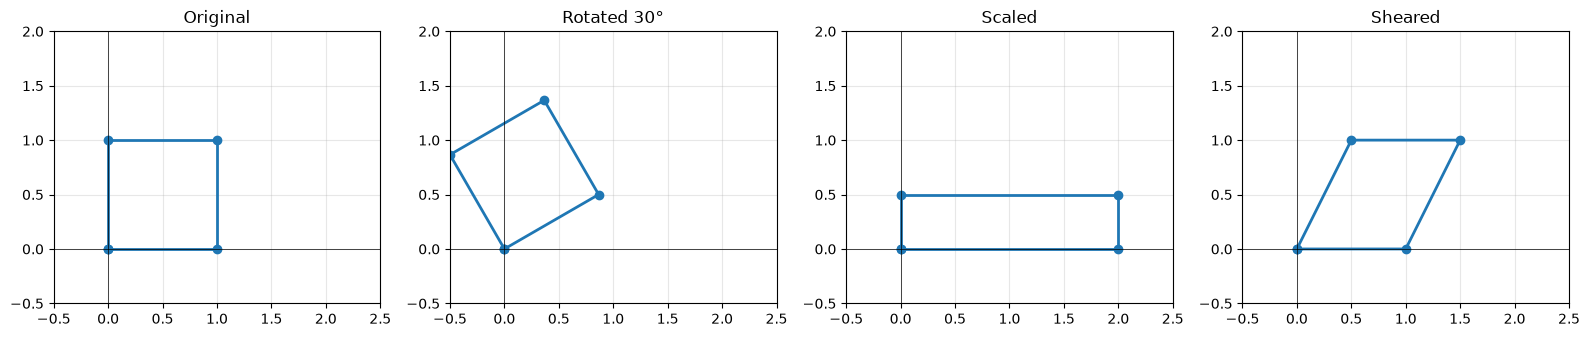

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def apply_transformation(square, matrix):
    """Apply a 2x2 transformation matrix to square corners.
    
    square: (4, 2) array of corner coordinates (rows are points)
    matrix: (2, 2) transformation matrix
    Returns: (4, 2) transformed corners
    """
    return square @ matrix.T   # (4,2) @ (2,2) -> (4,2)

def print_corners(name, corners):
    print(f"\n{name}:")
    for i, (x, y) in enumerate(corners):
        print(f"  corner {i}: ({x:.4f}, {y:.4f})")

def pairwise_distances(points):
    """Return matrix of distances between all pairs of points."""
    diff = points[:, None, :] - points[None, :, :]   # (N,N,2)
    return np.linalg.norm(diff, axis=-1)             # (N,N)

# --- Unit square corners (counter-clockwise) ---
square = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [1.0, 1.0],
    [0.0, 1.0],
])

print_corners("Original unit square", square)
orig_dists = pairwise_distances(square)

# ---------------------------------------------------------------
# 1. ROTATION  (preserves distances — orthogonal matrix, det = +1)
# ---------------------------------------------------------------
theta = np.deg2rad(30)
R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)],
])
rotated = apply_transformation(square, R)
print_corners(f"Rotated by {np.rad2deg(theta):.0f}°", rotated)

# Verify distances are preserved
rot_dists = pairwise_distances(rotated)
print("\nRotation preserves distances?",
      np.allclose(orig_dists, rot_dists, atol=1e-10))
print("Max distance error:", np.abs(orig_dists - rot_dists).max())

# ---------------------------------------------------------------
# 2. SCALING  (does NOT preserve distances)
# ---------------------------------------------------------------
S = np.array([
    [2.0, 0.0],   # scale x by 2
    [0.0, 0.5],   # scale y by 0.5
])
scaled = apply_transformation(square, S)
print_corners("Scaled (sx=2, sy=0.5)", scaled)

# ---------------------------------------------------------------
# 3. SHEARING  (does NOT preserve distances)
# ---------------------------------------------------------------
H = np.array([
    [1.0, 0.5],   # horizontal shear
    [0.0, 1.0],
])
sheared = apply_transformation(square, H)
print_corners("Sheared (kx=0.5)", sheared)

# ---------------------------------------------------------------
# Optional: visualize
# ---------------------------------------------------------------
def close_poly(c):
    return np.vstack([c, c[:1]])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, pts) in zip(axes, [
    ("Original", square), ("Rotated 30°", rotated),
    ("Scaled", scaled), ("Sheared", sheared)
]):
    p = close_poly(pts)
    ax.plot(p[:, 0], p[:, 1], 'o-', lw=2)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_title(title)
    ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.5, 2.0)

plt.tight_layout()
plt.show()

Find the eigenvalues of the matrix [[4, 2], [1, 3]] by hand using the characteristic equation. Then verify with your from-scratch function and with NumPy.

In [3]:
A=np.array([[4,2],[1,3]])
np.linalg.eig(A)

EigResult(eigenvalues=array([5.+0.j, 2.+0.j]), eigenvectors=array([[ 0.89442719+0.j, -0.70710678+0.j],
       [ 0.4472136 +0.j,  0.70710678+0.j]]))